# BiLSTM with GloVe Embeddings Benchmark — Symptoms Disease Classification


In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import zipfile
import os

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

device = "cuda" if torch.cuda.is_available() else "cpu"

c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset

In [2]:
ds = load_dataset("MartynaKopyta/hate_offensive_tweets")

train_ds = ds["train"].rename_column("text_cleaned", "text")
val_ds = ds["validation"].rename_column("text_cleaned", "text")
test_ds = ds["test"].rename_column("text_cleaned", "text")

train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 23541
})

In [3]:
train_ds[0]

{'text': 'RT _Dorsey: My trash is worth more than you', 'label': 2}

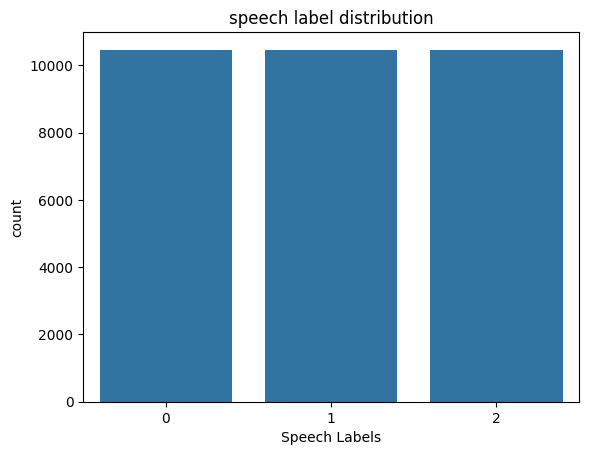

In [4]:
train = pd.DataFrame(ds["train"])
val = pd.DataFrame(ds["validation"])
test = pd.DataFrame(ds["test"])

df = pd.concat([train, val, test], ignore_index=True)

sns.countplot(data=df, x="label")
plt.title("speech label distribution")
plt.xlabel("Speech Labels")
plt.ylabel("count")
plt.show()

In [5]:
total_labels = len(set(train_ds["label"]))
print(f"Total number of labels: {total_labels}")

Total number of labels: 3


In [6]:
# label mappings
id2label = {0: "hate", 1: "offensive", 2: "neither"}
label2id = {v: k for k, v in id2label.items()}

## Tokenizer - Simple Whitespace Tokenizer


In [7]:
from collections import Counter
import re

def simple_tokenize(text):
    """Lowercase + split on non-alphanumeric. Matches GloVe preprocessing."""
    return re.findall(r"[a-zA-Z0-9]+", text.lower())

# Build vocab from training set only
counter = Counter()
for text in train_ds["text"]:
    counter.update(simple_tokenize(text))

# Special tokens: PAD=0, UNK=1
PAD_IDX = 0
UNK_IDX = 1

vocab = {"<PAD>": PAD_IDX, "<UNK>": UNK_IDX}

for word, _ in counter.most_common():
    vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)

print(f"Vocabulary size: {VOCAB_SIZE:,}")

Vocabulary size: 26,379


## Download GloVe Embeddings


In [8]:
GLOVE_DIR = "./glove"
GLOVE_ZIP = os.path.join(GLOVE_DIR, "glove.6B.zip")
GLOVE_FILE = os.path.join(GLOVE_DIR, "glove.6B.100d.txt")
EMBED_DIM = 100

os.makedirs(GLOVE_DIR, exist_ok=True)

if not os.path.exists(GLOVE_FILE):
    print("downloading glove")
    urllib.request.urlretrieve(
        "https://nlp.stanford.edu/data/glove.6B.zip",
        GLOVE_ZIP
    )
    print("extracting zip file")
    with zipfile.ZipFile(GLOVE_ZIP, "r") as zf:
        zf.extract("glove.6B.100d.txt", GLOVE_DIR)
    print("finished")
else:
    print("glove already exists")

glove already exists


In [9]:
# Load GloVe vectors for words in our vocabulary
glove_vectors = {}

with open(GLOVE_FILE, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        word = parts[0]
        if word in vocab:
            glove_vectors[word] = np.array(parts[1:], dtype=np.float32)

print(f"GloVe coverage: {len(glove_vectors):,} / {VOCAB_SIZE:,} vocab words "
      f"({100 * len(glove_vectors) / VOCAB_SIZE:.1f}%)")

# Build embedding matrix: PAD stays all-zeros, OOV gets random small init
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype=np.float32)
for word, idx in vocab.items():
    if word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]
    elif idx > 1:  # not PAD or UNK
        embedding_matrix[idx] = np.random.uniform(-0.1, 0.1, EMBED_DIM)

# UNK = mean of all known GloVe vectors
embedding_matrix[UNK_IDX] = np.mean(list(glove_vectors.values()), axis=0)

embedding_tensor = torch.tensor(embedding_matrix)

embedding_tensor.shape

GloVe coverage: 16,838 / 26,379 vocab words (63.8%)


torch.Size([26379, 100])

## Dataset & DataLoader

In [15]:
MAX_LEN = 256  # same max_length as RoBERTa tokenizer

class TextDataset(Dataset):
    def __init__(self, hf_split):
        self.texts = hf_split["text"]
        self.labels = hf_split["label"]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = simple_tokenize(self.texts[idx])[:MAX_LEN]
        ids = [vocab.get(t, UNK_IDX) for t in tokens]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

def collate_fn(batch):
    texts, labels = zip(*batch)
    lengths = torch.tensor([max(len(t), 1) for t in texts])
    padded = nn.utils.rnn.pad_sequence(
        [t if len(t) > 0 else torch.tensor([UNK_IDX]) for t in texts],
        batch_first=True,
        padding_value=PAD_IDX
    )
    return padded, torch.stack(labels), lengths

BATCH_SIZE = 16  # same as RoBERTa

train_dataset = TextDataset(train_ds)
val_dataset   = TextDataset(val_ds)
test_dataset  = TextDataset(test_ds)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 1472 | Val batches: 368 | Test batches: 123


## BiLSTM Model

In [16]:
class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_layers,
        num_classes,
        dropout=0.3,
        pretrained_embeddings=None,
        freeze_embeddings=False,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        if pretrained_embeddings is not None:
            self.embedding.weight = nn.Parameter(pretrained_embeddings)
            
        if freeze_embeddings:
            self.embedding.weight.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        # bidirectional → hidden_dim * 2
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, lengths):
        # input_ids: (batch, seq_len)
        x = self.dropout(self.embedding(input_ids))          # (batch, seq_len, embed_dim)

        # pack → LSTM efficiently skips PAD tokens
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        output, (hidden, _) = self.lstm(packed)               # hidden: (num_layers*2, batch, hidden)

        # Concatenate last forward and backward hidden states
        # hidden[-2] = last forward layer, hidden[-1] = last backward layer
        last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (batch, hidden*2)
        last_hidden = self.dropout(last_hidden)

        return self.classifier(last_hidden)                   # (batch, num_classes)


HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.3

model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=total_labels,
    dropout=DROPOUT,
    pretrained_embeddings=embedding_tensor,
    freeze_embeddings=False,   # allow fine-tuning GloVe weights
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"BiLSTM parameters: {total_params:,}")
print(model)

BiLSTM parameters: 4,949,583
BiLSTMClassifier(
  (embedding): Embedding(26379, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=512, out_features=3, bias=True)
)


## Training

In [17]:
LR = 1e-3        # Adam works well here; higher LR than transformers since we're not fine-tuning a large pretrain
NUM_EPOCH = 10   # BiLSTM trains faster per epoch, needs more epochs than transformers

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

os.makedirs("./results/bilstm", exist_ok=True)

best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

for epoch in range(1, NUM_EPOCH + 1):
    # ── Train ──
    model.train()
    total_loss = 0
    for batch_ids, batch_labels, batch_lengths in train_loader:
        batch_ids    = batch_ids.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        logits = model(batch_ids, batch_lengths)
        loss   = criterion(logits, batch_labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # ── Evaluate ──
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch_ids, batch_labels, batch_lengths in val_loader:
            batch_ids    = batch_ids.to(device)
            batch_labels = batch_labels.to(device)
            logits = model(batch_ids, batch_lengths)
            val_loss += criterion(logits, batch_labels).item()
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1  = f1_score(all_labels, all_preds, average="weighted")

    scheduler.step(avg_val_loss)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch:02d}/{NUM_EPOCH} | "
          f"train_loss: {avg_train_loss:.4f} | "
          f"val_loss: {avg_val_loss:.4f} | "
          f"accuracy: {val_acc:.4f} | "
          f"f1: {val_f1:.4f}")

    # save best model (mirrors load_best_model_at_end in TrainingArguments)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "./results/bilstm/best_model.pt")
        print(f"  → New best model saved (val_acc={val_acc:.4f})")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 01/10 | train_loss: 0.6431 | val_loss: 0.5471 | accuracy: 0.7516 | f1: 0.7365
  → New best model saved (val_acc=0.7516)
Epoch 02/10 | train_loss: 0.4850 | val_loss: 0.5017 | accuracy: 0.7662 | f1: 0.7573
  → New best model saved (val_acc=0.7662)
Epoch 03/10 | train_loss: 0.4080 | val_loss: 0.5457 | accuracy: 0.7671 | f1: 0.7518
  → New best model saved (val_acc=0.7671)
Epoch 04/10 | train_loss: 0.3445 | val_loss: 0.6065 | accuracy: 0.7603 | f1: 0.7534
Epoch 05/10 | train_loss: 0.2989 | val_loss: 0.6643 | accuracy: 0.7547 | f1: 0.7447
Epoch 06/10 | train_loss: 0.2435 | val_loss: 0.7990 | accuracy: 0.7450 | f1: 0.7380
Epoch 07/10 | train_loss: 0.2256 | val_loss: 0.8475 | accuracy: 0.7446 | f1: 0.7367
Epoch 08/10 | train_loss: 0.2120 | val_loss: 0.8933 | accuracy: 0.7407 | f1: 0.7354
Epoch 09/10 | train_loss: 0.1916 | val_loss: 1.0015 | accuracy: 0.7462 | f1: 0.7389
Epoch 10/10 | train_loss: 0.1799 | val_loss: 1.1063 | accuracy: 0.7429 | f1: 0.7358

Best validation accuracy: 0.7671


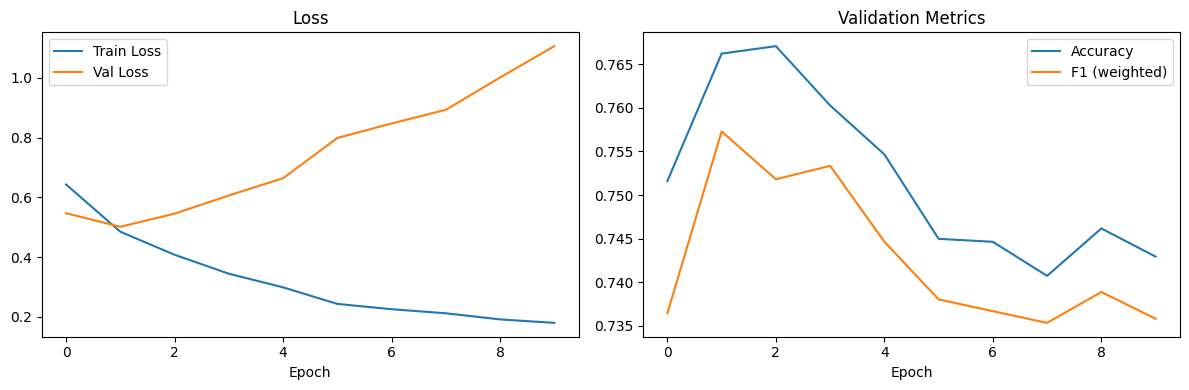

In [18]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["val_acc"], label="Accuracy")
axes[1].plot(history["val_f1"],  label="F1 (weighted)")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## Model Evaluation


In [19]:
# Load best checkpoint before final evaluation
model.load_state_dict(torch.load("./results/bilstm/best_model.pt", map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch_ids, batch_labels, batch_lengths in test_loader:
        logits = model(batch_ids.to(device), batch_lengths)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch_labels.numpy())

final_acc = accuracy_score(all_labels, all_preds)
final_f1  = f1_score(all_labels, all_preds, average="weighted")
print(f"Final  accuracy : {final_acc:.4f}")
print(f"Final  F1 (weighted): {final_f1:.4f}")

Final  accuracy : 0.7717
Final  F1 (weighted): 0.7579


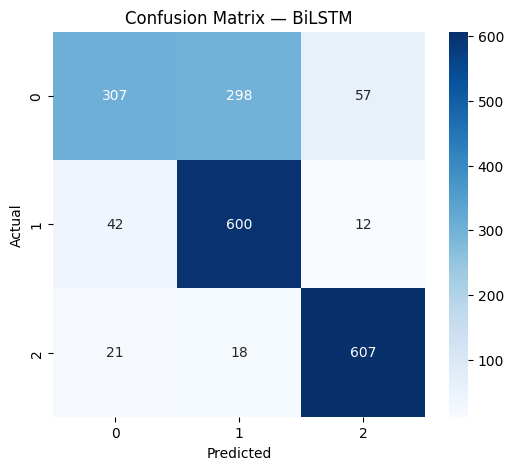

In [20]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — BiLSTM")
plt.show()

In [21]:
report = classification_report(all_labels, all_preds, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.head(total_labels + 4)

,precision,recall,f1-score,support
0,0.829730,0.463746,0.594961,662.000000
1,0.655022,0.917431,0.764331,654.000000
2,0.897929,0.939628,0.918306,646.000000
accuracy,0.771662,0.771662,0.771662,0.771662
macro avg,0.794227,0.773602,0.759199,1962.000000
weighted avg,0.793949,0.771662,0.757881,1962.000000


## Save Model & Vocab


In [22]:
import json

# Save vocab and label mappings so inference can be loaded standalone
with open("./results/bilstm/vocab.json", "w") as f:
    json.dump(vocab, f)

with open("./results/bilstm/id2label.json", "w") as f:
    json.dump(id2label, f)

# Save model config for reloading
model_config = {
    "vocab_size": VOCAB_SIZE,
    "embed_dim": EMBED_DIM,
    "hidden_dim": HIDDEN_DIM,
    "num_layers": NUM_LAYERS,
    "num_classes": total_labels,
    "dropout": DROPOUT,
}
with open("./results/bilstm/config.json", "w") as f:
    json.dump(model_config, f)

print("Saved to ./results/bilstm/")

Saved to ./results/bilstm/


## Inference Example

In [24]:
import json

# ── Reload from disk (mirrors the RoBERTa inference cell) ──
with open("./results/bilstm/vocab.json")    as f: vocab    = json.load(f)
with open("./results/bilstm/id2label.json") as f: id2label = json.load(f)
with open("./results/bilstm/config.json")   as f: cfg      = json.load(f)

# Re-instantiate without pretrained embeddings (weights come from checkpoint)
inference_model = BiLSTMClassifier(
    vocab_size=cfg["vocab_size"],
    embed_dim=cfg["embed_dim"],
    hidden_dim=cfg["hidden_dim"],
    num_layers=cfg["num_layers"],
    num_classes=cfg["num_classes"],
    dropout=cfg["dropout"],
).to(device)

inference_model.load_state_dict(torch.load("./results/bilstm/best_model.pt", map_location=device))
inference_model.eval()

def predict(text):
    tokens = simple_tokenize(text)[:MAX_LEN]
    ids    = torch.tensor([[vocab.get(t, UNK_IDX) for t in tokens]], dtype=torch.long).to(device)
    length = torch.tensor([len(tokens)])
    with torch.no_grad():
        logits = inference_model(ids, length)
        probs  = torch.softmax(logits, dim=1)
        pred_id = probs.argmax(dim=1).item()
    return [{"label": id2label[str(pred_id)], "score": probs[0, pred_id].item()}]

predict("you are so stupid")

[{'label': 'hate', 'score': 0.6371878385543823}]